### Load intro stuff:

In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
%matplotlib inline

### Choose what ALMA bands you are focusing on:

In [4]:
bands = [4, 6, 7]
num_bands = len(bands)

### If it is my own data and we can get the POLF average from other notebooks, load it here:

In [5]:
POLF_avg = []

for band in bands:
    path = globals()[f"band{band}_data_folder_path"]  # get the variable holding the path
    df = pd.read_csv(path + f"constants_BAND{band}.csv")
    POLF_avg.append(df["POLF_avg"].values[0] * 100)  # get the scalar value (from array)

### Band Wavelengths and Colours

In [6]:
band_colors = [alma_band_colors[b] for b in bands]

In [7]:
lambda_bands_cm = mm_to_cm([lambda_mm[b] for b in bands])

### Run DSHARP

Load the standard DSHARP dust mixture optical constants (oc) and density (rho_s)

In [8]:
oc, rho_g_cm3 = do.get_dsharp_mix()

Please cite Warren & Brandt (2008) when using these optical constants
Please cite Draine 2003 when using these optical constants
Reading opacities from troilitek
Please cite Henning & Stognienko (1996) when using these optical constants
Reading opacities from organicsk
Please cite Henning & Stognienko (1996) when using these optical constants
| material                            | volume fractions | mass fractions |
|-------------------------------------|------------------|----------------|
| Water Ice (Warren & Brandt 2008)    | 0.3642           | 0.2            |
| Astronomical Silicates (Draine 2003)| 0.167            | 0.329          |
| Troilite (Henning)                  | 0.02578          | 0.07434        |
| Organics (Henning)                  | 0.443            | 0.3966         |


## Kataoka et al. 2015, Figure 1

In [9]:
logwave_vals = np.linspace(0, 4, 5000)
lambda_micron_fig1 = 10**logwave_vals

lambda_cm_fig1 = micron_to_cm(lambda_micron_fig1)

print(rf'Wavelength ranges from:')
print(rf"min: {np.min(lambda_micron_fig1)} microns")
print(rf"max: {np.max(lambda_micron_fig1)} microns")

Wavelength ranges from:
min: 1.0 microns
max: 10000.0 microns


In [10]:
a_max_micron_fig1 = [1, 100]
a_max_cm_fig1 = micron_to_cm(a_max_micron_fig1)

In [11]:
res_fig1 = do.get_opacities(a_max_cm_fig1, lambda_cm_fig1, rho_g_cm3 , oc, extrapolate_large_grains=False, n_angle=100)

k_abs_fig1 = res_fig1['k_abs']
k_sca_fig1 = res_fig1['k_sca']
S1_fig1    = res_fig1['S1']
S2_fig1    = res_fig1['S2']
theta_fig1 = res_fig1['theta']

Mie ... Done!


(0.001, 100000.0)

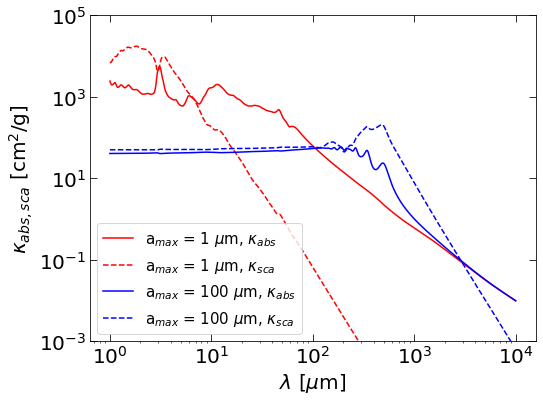

In [12]:
# Create a figure with the WCS projection
fig, ax = plt.subplots(figsize=(8, 6))

fig1_colors = ['red', 'blue']

for i in range(2):
    ax.plot(lambda_micron_fig1,
            k_abs_fig1[i],
            color = fig1_colors[i],
            ls = '-',
            label = rf'a$_{{max}}$ = {a_max_micron_fig1[i]} $\mu$m, $\kappa_{{abs}}$')

    ax.plot(lambda_micron_fig1,
            k_sca_fig1[i],
            color = fig1_colors[i],
            ls = '--',
            label = rf'a$_{{max}}$ = {a_max_micron_fig1[i]} $\mu$m, $\kappa_{{sca}}$')


# Add axis labels
ax.set_xlabel('$\lambda$ [$\mu$m]', fontsize=axis_label_fs)
ax.set_ylabel('$\kappa_{abs, sca}$ [cm$^2$/g]', fontsize=axis_label_fs)


# Adjust ticks
ax.minorticks_on()
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

ax.legend(loc = 'lower left',
          fontsize = legend_text_fs)

# Make axes log if needed
ax.set_xscale('log')
ax.set_yscale('log')

# Set axis limits
# ax.setxlim()
ax.set_ylim(10e-4, 10e4)

## Kataoka et al. 2015, Figure 2

In [13]:
# From Kataoka et 1l, 2015 the grain sizes they are showing are 10 micron, 100 micron, 1 mm and 1 cm
fig2_labels = ['10 $\mu$m', '100 $\mu$m', '1 mm', '1 cm']

a_max_micron_fig2 = [10, 100, 1000, 10000]
a_max_cm_fig2 = micron_to_cm(a_max_micron_fig2)

In [14]:
a_min = 0.005e-4  # 0.05 micron in cm
a_grid = np.logspace(np.log10(a_min), np.log10(max(a_max_cm_fig2)), 500)

In [15]:
mass_grams_fig2 = calculate_grain_mass(a_max_cm_fig2, rho_g_cm3, "cm")

In [16]:
fig2_bands = [4, 7]

fig2_indices = [bands.index(b) for b in fig2_bands]

In [17]:
lambda_micron_fig2 = [lambda_mm[fig2_bands[0]], lambda_mm[fig2_bands[1]]]
lambda_cm_fig2 = mm_to_cm(lambda_micron_fig2)

print('We are going to be using lambda values of:')

for lam_cm in lambda_cm_fig2:
    print(rf'{lam_cm:.3f} cm')

We are going to be using lambda values of:
0.200 cm
0.087 cm


In [18]:
# ---- a grid for grain distribution ----
a_dist_fig2 = np.logspace(np.log10(1e-4), np.log10(1e-1), 200)  # cm
distri_template = a_dist_fig2**0.5

In [19]:
mass_grams_fig2 = calculate_grain_mass(a_dist_fig2, rho_g_cm3, "cm")

In [20]:
# ---- Opacity and Mueller matrix ----
res = do.get_opacities(a_dist_fig2, lambda_cm_fig2, rho_g_cm3, oc, extrapolate_large_grains=False, n_angle=100)
k_abs, k_sca = res['k_abs'], res['k_sca']
S1, S2 = res['S1'], res['S2']
theta = res['theta']  # degrees

zscat = do.calculate_mueller_matrix(lambda_cm_fig2, mass_grams_fig2 , S1, S2, theta=theta, k_sca=k_sca)['zscat']

Mie ... Done!


In [21]:
scatt_angles_deg = np.linspace(0, 180, 5000)

In [22]:
# ---- Initialize ----
Z11eff = np.zeros((len(a_max_cm_fig2), len(lambda_cm_fig2), len(scatt_angles_deg)))
Z12eff = np.zeros_like(Z11eff)
omega = np.zeros((len(a_max_cm_fig2), len(lambda_cm_fig2)))

# ---- Loop over a_max ----
for ia, amax in enumerate(a_max_cm_fig2):
    distri = distri_template.copy()
    distri[a_dist_fig2 > amax] = 0
    distri /= distri.sum()

    for iw in range(len(lambda_cm_fig2)):
        z11_avg = np.sum(zscat[:, iw, :, 0] * distri[:, None], axis=0)
        z12_avg = np.sum(zscat[:, iw, :, 1] * distri[:, None], axis=0)

        f_z11 = interp1d(theta, z11_avg, kind='linear', bounds_error=False, fill_value="extrapolate")
        f_z12 = interp1d(theta, z12_avg, kind='linear', bounds_error=False, fill_value="extrapolate")

        Z11eff[ia, iw, :] = f_z11(scatt_angles_deg)
        Z12eff[ia, iw, :] = f_z12(scatt_angles_deg)

        k_a = np.sum(k_abs[:, iw] * distri)
        k_s = np.sum(k_sca[:, iw] * distri)
        omega[ia, iw] = k_s / (k_a + k_s)
        
P_eff = -Z12eff / Z11eff

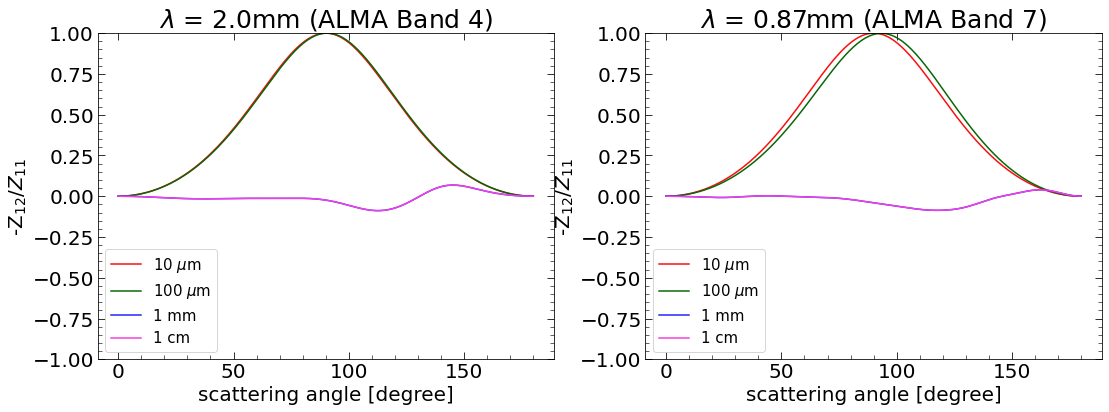

In [23]:
# Plotting
fig, ax = plt.subplots(1, 2, figsize=(18, 6))


for i in range(4):
    ax[0].plot(scatt_angles_deg, P_eff[:, 0, :][i], color = kataoka_fig2_colors[i], label = fig2_labels[i])
    ax[1].plot(scatt_angles_deg, P_eff[:, 1, :][i], color = kataoka_fig2_colors[i], label = fig2_labels[i])

# Add titles
# Titles
for i in range(2):
    ax[i].set_title(rf'$\lambda$ = {lambda_mm[fig2_bands[i]]}mm (ALMA Band {fig2_bands[i]})', fontsize=title_fs)

# Adjust ticks
for i in range(2):
    # Set axis labels
    ax[i].set_ylabel('-Z$_{12}/Z_{11}$', fontsize = axis_label_fs)
    ax[i].set_xlabel('scattering angle [degree]', fontsize = axis_label_fs)
    
    # Axis ticks
    ax[i].minorticks_on()
    
    ax[i].tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
    ax[i].tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)


    ax[i].tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    ax[i].tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

    # Add a legend
    ax[i].legend(fontsize = legend_text_fs, loc = 'lower left')
    
    # Set y-lim
    ax[i].set_ylim(-1, 1)


## Kataoka et al. 2015, Figure 3

The x-axis of Figures 3 and 4 is maximum grain size in cm, ranging from 0.001 to 1 cm

In [24]:
a_max_cm = np.logspace(-3, 0, 100)

print(rf'The lower bound of a_max is: {np.min(a_max_cm)} cm')
print(rf'The upper bound of a_max is: {np.max(a_max_cm)} cm')

The lower bound of a_max is: 0.001 cm
The upper bound of a_max is: 1.0 cm


In [25]:
mass_grams = calculate_grain_mass(a_max_cm, rho_g_cm3, "cm")

In [26]:
print('We are going to be using lambda values of:')

for lam_cm in lambda_bands_cm:
    print(rf'{lam_cm:.3f} cm')

We are going to be using lambda values of:
0.200 cm
0.130 cm
0.087 cm


In [27]:
res = do.get_opacities(a_max_cm, lambda_bands_cm, rho_g_cm3 , oc, extrapolate_large_grains=False, n_angle=100)

k_abs = res['k_abs']
k_sca = res['k_sca']
S1    = res['S1']
S2    = res['S2']
theta = res['theta']

# index where theta = 90 degree

i90 = theta.searchsorted(90)

Mie ... Done!


In [28]:
zscat = do.calculate_mueller_matrix(lambda_bands_cm, mass_grams, S1, S2, theta=theta, k_sca=k_sca)['zscat']

/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:2116: UserWarning: Maximum error of 9.6%: above error tolerance
  warnings.warn(


In [29]:
# Initialize arrays for results
Z11eff = np.zeros([len(a_max_cm), len(lambda_bands_cm)])
Z12eff = np.zeros_like(Z11eff)
omega_array = np.zeros_like(Z11eff)

# Loop over maximum grain sizes
for ia, amax in enumerate(a_max_cm):
    # Create normalized MRN distribution truncated at current max grain size
    distri = a_max_cm**0.5
    distri[a_max_cm > amax] = 0
    distri /= distri.sum()
    
    # Average scattering matrix elements at 90 deg scattering angle
    Z11eff[ia] = np.sum(zscat[:, :, i90, 0] * distri[:, None], axis=0)
    Z12eff[ia] = np.sum(zscat[:, :, i90, 1] * distri[:, None], axis=0)
    
    # Average opacities to get average albedo omega
    k_a = np.sum(k_abs * distri[:, None], axis=0)
    k_s = np.sum(k_sca * distri[:, None], axis=0)
    omega_array[ia] = k_s / (k_a + k_s)

In [30]:
omega = [omega_array[:, i] for i in range(num_bands)]

In [31]:
# Calculate polarization fraction at 90 degree
P_array = np.abs(Z12eff / Z11eff)

P = [P_array[:, i] for i in range(num_bands)]

In [32]:
fig3_bands = [4, 7]

fig3_indices = [bands.index(b) for b in fig3_bands]

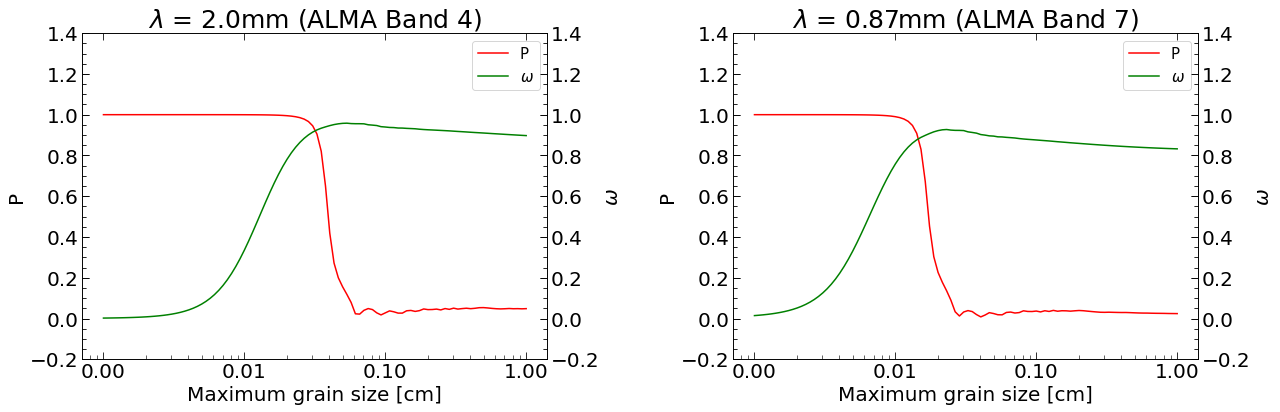

In [33]:
# Plotting
fig, ax = plt.subplots(1, 2, figsize=(20, 6))  # Wider figure for spacing

# Create secondary y-axes
ax2_0 = ax[0].twinx()
ax2_1 = ax[1].twinx()

# Plot on the left
ax0_P,     = ax[0].plot(a_max_cm, P[fig3_indices[0]],    color='red', label='P')
ax0_omega, = ax2_0.plot(a_max_cm, omega[fig3_indices[0]], color='green', label=r'$\omega$')

# Plot on the right
ax1_P,     = ax[1].plot(a_max_cm, P[fig3_indices[1]], color='red', label='P')
ax1_omega, = ax2_1.plot(a_max_cm, omega[fig3_indices[1]], color='green', label=r'$\omega$')

# Titles
for i in range(2):
    ax[i].set_title(rf'$\lambda$ = {lambda_mm[fig3_bands[i]]}mm (ALMA Band {fig3_bands[i]})', fontsize=title_fs)
    ax[i].set_xlabel('Maximum grain size [cm]', fontsize=axis_label_fs)
    ax[i].set_ylabel('P', fontsize=axis_label_fs)
    
    
        # Make axes log if needed
    ax[i].set_xscale('log')
#     ax[i].set_yscale('log')

    # Remove scientific notation from x-axis
    ax[i].xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
    ax[i].ticklabel_format(style='plain', axis='x')


ax2_0.set_ylabel(r'$\omega$', fontsize=axis_label_fs)
ax2_1.set_ylabel(r'$\omega$', fontsize=axis_label_fs)

# Ticks
for a in [ax[0], ax[1], ax2_0, ax2_1]:
    a.minorticks_on()
    a.tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
    a.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)
    
    a.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
    a.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)

    a.set_ylim(-0.2, 1.4)


# Single legend per subplot
ax[0].legend(handles = [ax0_P, ax0_omega], fontsize = legend_text_fs, loc = 'upper right')
ax[1].legend(handles = [ax1_P, ax1_omega], fontsize = legend_text_fs, loc = 'upper right')

# Add spacing between subplots
plt.subplots_adjust(wspace=0.4)

## Kataoka et al. 2015, Figure 4

In [34]:
# P = [P_band4, P_band6, P_band7]
# omega = [omega_band4, omega_band6, omega_band7]

P_times_omega = []

for i in range(len(bands)):
    P_times_omega.append(P[i] * omega[i])

In [35]:
top_label = []
bottom_label = []

for band in bands:
    top = f"{lambda_mm[band]} mm"
    bottom = f"(Band {band})"
    
    top_label.append(top)
    bottom_label.append(bottom)

bottom_label

['(Band 4)', '(Band 6)', '(Band 7)']

(-0.1, 1.6)

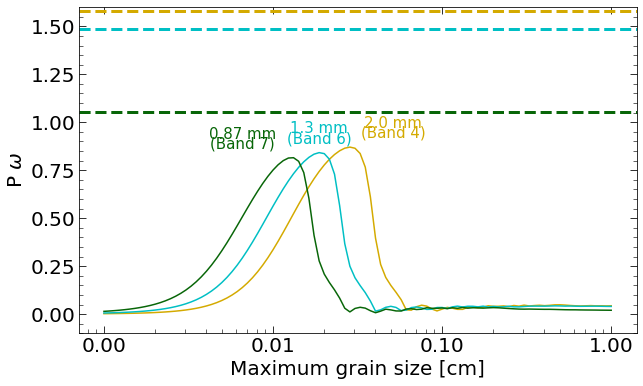

In [36]:
# Create a figure with the WCS projection
fig, ax = plt.subplots(figsize=(10, 6))

for i in range(num_bands):
    ax.plot(a_max_cm,
            P_times_omega[i],
            color = band_colors[i],
            ls = '-')


# Add axis labels
ax.set_xlabel('Maximum grain size [cm]', fontsize=axis_label_fs)
ax.set_ylabel('P $\omega$', fontsize=axis_label_fs)


# Adjust ticks
ax.minorticks_on()

ax.tick_params(axis="x", which="minor", direction="in", left=True, right=True, length=4)
ax.tick_params(axis="y", which="minor", direction="in", left=True, right=True, length=4)
    
ax.tick_params(axis="x", which="major", direction="in", bottom=True, top=True, length=7, labelsize=axis_num_fs)
ax.tick_params(axis="y", which="major", direction="in", left=True, right=True, length=7, labelsize=axis_num_fs)



# Make axes log if needed
ax.set_xscale('log')
# ax.set_yscale('log')

# Remove scientific notation from x-axis
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
ax.ticklabel_format(style='plain', axis='x')

fs = 15
x_offset = [1.8, 1, 0.5]

for i in range(num_bands):
    y_loc = np.max(P_times_omega[i])
    idx = np.argmax(P_times_omega[i])
    x_loc = a_max_cm[idx]

    # Offset value can be tuned depending on your data scale
    ax.text(x_loc * x_offset[i], y_loc + 0.1,  # top label slightly above peak
            top_label[i],
            color=band_colors[i],
            fontsize=fs,
            ha='center')

    ax.text(x_loc * x_offset[i], y_loc + 0.05,  # bottom label at peak
            bottom_label[i],
            color=band_colors[i],
            fontsize=fs,
            ha='center')
    
# Add horizontal lines of POLF_avg at each band if my own data
for i in range(num_bands):
    ax.axhline(POLF_avg[i], color = band_colors[i], ls = '--', lw = 3)

ax.set_ylim(-0.1, 1.6)